In [ ]:
# ============================================================
# EMBER-X PHASE 1
# Emotion Detection + Emotional Memory
# ============================================================

!pip -q install transformers torch pandas accelerate

import sqlite3
import pandas as pd
from transformers import pipeline
from datetime import datetime

# ============================================================
# Load Emotion Detection Model
# ============================================================

print("Loading Emotion Model...")

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

print("Model Loaded Successfully!")

# ============================================================
# Create SQLite Database
# ============================================================

conn = sqlite3.connect("ember_memory.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS emotion_history (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT,
    text TEXT,
    emotion TEXT,
    confidence REAL
)
""")

conn.commit()

# ============================================================
# Example Mental Health Conversations
# ============================================================

sample_texts = [
    "I feel anxious about my future.",
    "Nothing seems enjoyable anymore.",
    "I am stressed because of my exams.",
    "I feel lonely and exhausted.",
    "Everything feels overwhelming.",
    "I cannot sleep properly.",
    "I am worried all the time.",
    "I feel hopeless.",
    "I am happy today.",
    "Life feels meaningless."
]

# ============================================================
# Detect Emotion + Store in Database
# ============================================================

records = []

for text in sample_texts:

    prediction = emotion_classifier(text)[0]

    top_emotion = max(prediction, key=lambda x: x["score"])

    emotion = top_emotion["label"]
    confidence = float(top_emotion["score"])

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    cursor.execute("""
    INSERT INTO emotion_history
    (timestamp,text,emotion,confidence)
    VALUES (?,?,?,?)
    """, (timestamp, text, emotion, confidence))

    records.append({
        "Text": text,
        "Emotion": emotion,
        "Confidence": round(confidence, 4)
    })

conn.commit()

# ============================================================
# Display Results
# ============================================================

df = pd.DataFrame(records)

print("\nEmotion Detection Results\n")
display(df)

# ============================================================
# Emotion Persistence Score (EPS)
# EPS = Avg Confidence × Frequency
# ============================================================

query = pd.read_sql_query(
    "SELECT emotion, confidence FROM emotion_history",
    conn
)

emotion_stats = (
    query.groupby("emotion")
    .agg(
        Frequency=("emotion", "count"),
        AvgConfidence=("confidence", "mean")
    )
)

emotion_stats["EPS"] = (
    emotion_stats["Frequency"]
    * emotion_stats["AvgConfidence"]
)

emotion_stats = emotion_stats.sort_values(
    "EPS",
    ascending=False
)

print("\nEmotion Persistence Scores (EPS)\n")
display(emotion_stats)

# ============================================================
# Dominant Emotional Trend
# ============================================================

dominant_emotion = emotion_stats.index[0]
dominant_eps = emotion_stats.iloc[0]["EPS"]

print("=" * 60)
print(f"Dominant Emotion : {dominant_emotion}")
print(f"EPS Score        : {dominant_eps:.3f}")
print("=" * 60)

# ============================================================
# Memory Summary
# ============================================================

memory_summary = f"""
User Emotional Memory Summary

Dominant Emotion:
{dominant_emotion}

Observed Frequency:
{emotion_stats.iloc[0]['Frequency']}

Average Confidence:
{emotion_stats.iloc[0]['AvgConfidence']:.2f}

Emotion Persistence Score:
{dominant_eps:.2f}
"""

print(memory_summary)

conn.close()

Loading Emotion Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

Model Loaded Successfully!

Emotion Detection Results



,Text,Emotion,Confidence
0,I feel anxious about my future.,fear,0.9933
1,Nothing seems enjoyable anymore.,sadness,0.9595
2,I am stressed because of my exams.,anger,0.8033
3,I feel lonely and exhausted.,sadness,0.9888
4,Everything feels overwhelming.,surprise,0.5299
5,I cannot sleep properly.,sadness,0.9523
6,I am worried all the time.,fear,0.9789
7,I feel hopeless.,sadness,0.9803
8,I am happy today.,joy,0.9781
9,Life feels meaningless.,sadness,0.9330



Emotion Persistence Scores (EPS)



,Frequency,AvgConfidence,EPS
emotion,,,
sadness,5,0.962779,4.813897
fear,2,0.986142,1.972284
joy,1,0.978105,0.978105
anger,1,0.803336,0.803336
surprise,1,0.529931,0.529931


Dominant Emotion : sadness
EPS Score        : 4.814

User Emotional Memory Summary

Dominant Emotion:
sadness

Observed Frequency:
5.0

Average Confidence:
0.96

Emotion Persistence Score:
4.81



In [ ]:
# ============================================================
# EMBER-X PHASE 2
# Temporal Emotional Memory + Drift Detection
# ============================================================

!pip -q install transformers pandas torch accelerate

import sqlite3
import pandas as pd
from transformers import pipeline
from datetime import datetime

# ============================================================
# Load Emotion Model
# ============================================================

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

print("Emotion model loaded.")

# ============================================================
# Create Database
# ============================================================

conn = sqlite3.connect("ember_memory_v2.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS emotion_history (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id TEXT,
    timestamp TEXT,
    text TEXT,
    emotion TEXT,
    confidence REAL,
    summary TEXT
)
""")

conn.commit()

# ============================================================
# Example Conversations
# ============================================================

conversations = [

    {
        "date":"2026-06-01",
        "text":"I am worried about my exams."
    },

    {
        "date":"2026-06-05",
        "text":"I cannot sleep properly."
    },

    {
        "date":"2026-06-10",
        "text":"Nothing feels enjoyable anymore."
    },

    {
        "date":"2026-06-15",
        "text":"I feel lonely and exhausted."
    },

    {
        "date":"2026-06-20",
        "text":"Life feels meaningless."
    }

]

USER_ID = "user_001"

# ============================================================
# Emotion Detection + Storage
# ============================================================

records = []

for conv in conversations:

    prediction = emotion_classifier(conv["text"])[0]

    top_emotion = max(
        prediction,
        key=lambda x: x["score"]
    )

    emotion = top_emotion["label"]
    confidence = float(top_emotion["score"])

    cursor.execute("""
    INSERT INTO emotion_history
    (
      user_id,
      timestamp,
      text,
      emotion,
      confidence,
      summary
    )
    VALUES (?,?,?,?,?,?)
    """,
    (
      USER_ID,
      conv["date"],
      conv["text"],
      emotion,
      confidence,
      conv["text"]
    ))

    records.append({
        "Date":conv["date"],
        "Text":conv["text"],
        "Emotion":emotion,
        "Confidence":round(confidence,3)
    })

conn.commit()

df = pd.DataFrame(records)

print("\nConversation Emotion History\n")
display(df)

# ============================================================
# Temporal Emotional Trend Score (TETS)
# Recent conversations receive larger weights
# ============================================================

emotion_df = pd.read_sql_query(
    """
    SELECT *
    FROM emotion_history
    WHERE user_id='user_001'
    ORDER BY timestamp
    """,
    conn
)

emotion_df["weight"] = range(
    1,
    len(emotion_df)+1
)

emotion_df["weighted_score"] = (
    emotion_df["confidence"]
    *
    emotion_df["weight"]
)

tets = (
    emotion_df
    .groupby("emotion")
    .apply(
        lambda x:
        x["weighted_score"].sum()
        /
        x["weight"].sum()
    )
)

tets = tets.sort_values(
    ascending=False
)

print("\nTemporal Emotional Trend Score (TETS)\n")
display(tets)

dominant_emotion = tets.index[0]

# ============================================================
# Emotion Drift Detection
# ============================================================

emotion_sequence = emotion_df["emotion"].tolist()

print("\nEmotion Sequence:\n")
print(" -> ".join(emotion_sequence))

previous_emotion = emotion_sequence[-2]
current_emotion = emotion_sequence[-1]

negative_emotions = [
    "sadness",
    "fear",
    "anger",
    "disgust"
]

if (
    current_emotion in negative_emotions
    and previous_emotion != current_emotion
):
    trend = "Worsening"

elif current_emotion == previous_emotion:
    trend = "Persistent"

else:
    trend = "Stable"

# ============================================================
# Emotional Memory Summary
# ============================================================

memory_summary = f"""
====================================================

EMOTIONAL MEMORY SUMMARY

Dominant Emotion:
{dominant_emotion}

Previous Emotion:
{previous_emotion}

Current Emotion:
{current_emotion}

Trend:
{trend}

Number of Sessions:
{len(emotion_df)}

====================================================
"""

print(memory_summary)

conn.close()

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Emotion model loaded.

Conversation Emotion History



,Date,Text,Emotion,Confidence
0,2026-06-01,I am worried about my exams.,fear,0.988
1,2026-06-05,I cannot sleep properly.,sadness,0.952
2,2026-06-10,Nothing feels enjoyable anymore.,joy,0.869
3,2026-06-15,I feel lonely and exhausted.,sadness,0.989
4,2026-06-20,Life feels meaningless.,sadness,0.933



Temporal Emotional Trend Score (TETS)



/tmp/ipykernel_704/3486214401.py:163: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,0
emotion,
fear,0.987893
sadness,0.956804
joy,0.869101



Emotion Sequence:

fear -> sadness -> joy -> sadness -> sadness


EMOTIONAL MEMORY SUMMARY

Dominant Emotion:
fear

Previous Emotion:
sadness

Current Emotion:
sadness

Trend:
Persistent

Number of Sessions:
5




Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


Detected Emotional States



,date,text,raw_emotion,mental_state,confidence
0,2026-06-01,I am worried about my exams.,fear,anxiety,0.987893
1,2026-06-05,I cannot sleep properly.,sadness,depression,0.952348
2,2026-06-10,Nothing feels enjoyable anymore.,joy,positive,0.869101
3,2026-06-15,I feel lonely and exhausted.,sadness,depression,0.988802
4,2026-06-20,Life feels meaningless.,sadness,depression,0.932989
5,2026-06-25,I don't feel motivated to do anything.,joy,positive,0.977144



EHRI RESULTS
Dominant State     : depression
Persistence Score  : 0.500
TETS Score         : 0.952
Trend Score        : 0.667
Risk Component     : 0.633
------------------------------
EHRI               : 0.714
Risk Level         : MEDIUM


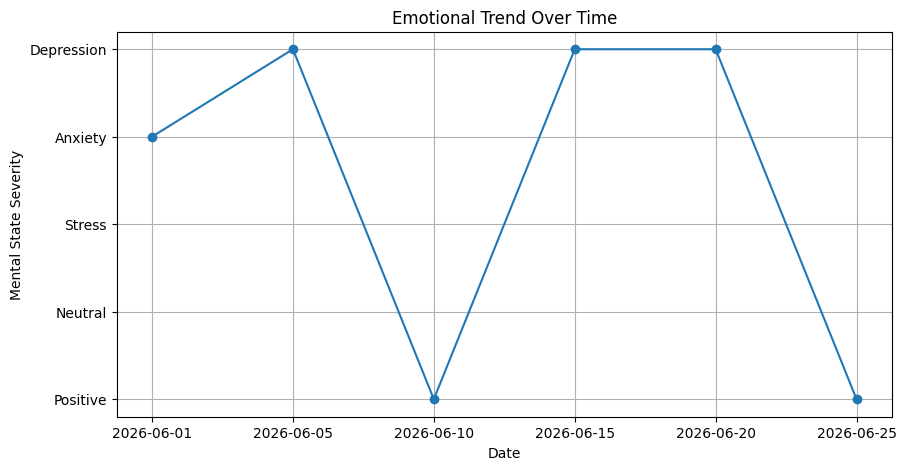


USER EMOTIONAL MEMORY

Dominant State:
depression

Current Risk:
MEDIUM

EHRI:
0.714

Recent Trend:
['depression', 'depression', 'positive']

Recommendation:
Use this memory during RAG retrieval and
response generation.



In [ ]:
# ============================================================
# EMBER-X PHASE 2.5
# Mental Health Emotion Mapper + EHRI
# ============================================================

!pip -q install transformers pandas matplotlib accelerate torch

import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

# ============================================================
# Emotion Model
# ============================================================

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

# ============================================================
# Example User Sessions
# ============================================================

conversations = [

    ("2026-06-01", "I am worried about my exams."),
    ("2026-06-05", "I cannot sleep properly."),
    ("2026-06-10", "Nothing feels enjoyable anymore."),
    ("2026-06-15", "I feel lonely and exhausted."),
    ("2026-06-20", "Life feels meaningless."),
    ("2026-06-25", "I don't feel motivated to do anything.")
]

# ============================================================
# Mental Health Emotion Mapping
# ============================================================

EMOTION_MAP = {

    "fear": "anxiety",
    "sadness": "depression",
    "anger": "stress",
    "joy": "positive",
    "neutral": "neutral",
    "surprise": "neutral",
    "disgust": "stress"
}

# ============================================================
# Risk Weights
# ============================================================

RISK_WEIGHT = {

    "depression": 1.0,
    "anxiety": 0.8,
    "stress": 0.6,
    "neutral": 0.2,
    "positive": 0.0
}

# ============================================================
# Run Detection
# ============================================================

records = []

for date, text in conversations:

    preds = emotion_classifier(text)[0]

    top = max(preds, key=lambda x: x["score"])

    raw_emotion = top["label"]

    confidence = float(top["score"])

    mental_state = EMOTION_MAP.get(
        raw_emotion,
        "neutral"
    )

    records.append({
        "date": date,
        "text": text,
        "raw_emotion": raw_emotion,
        "mental_state": mental_state,
        "confidence": confidence
    })

df = pd.DataFrame(records)

print("\nDetected Emotional States\n")
display(df)

# ============================================================
# Persistence
# ============================================================

state_counts = (
    df["mental_state"]
    .value_counts()
    .to_dict()
)

dominant_state = max(
    state_counts,
    key=state_counts.get
)

persistence_score = (
    state_counts[dominant_state]
    /
    len(df)
)

# ============================================================
# Recency Weighted TETS
# ============================================================

weights = list(
    range(
        1,
        len(df)+1
    )
)

df["weight"] = weights

df["weighted_conf"] = (
    df["confidence"]
    *
    df["weight"]
)

tets = (
    df["weighted_conf"].sum()
    /
    df["weight"].sum()
)

# ============================================================
# Trend Detection
# ============================================================

negative_states = [
    "depression",
    "anxiety",
    "stress"
]

last_three = (
    df["mental_state"]
    .tail(3)
    .tolist()
)

negative_count = sum(
    s in negative_states
    for s in last_three
)

trend_score = (
    negative_count
    /
    3
)

# ============================================================
# EHRI
# ============================================================

risk_component = (
    df["mental_state"]
    .map(RISK_WEIGHT)
    .mean()
)

ehri = (
    0.4 * tets
    +
    0.4 * persistence_score
    +
    0.2 * trend_score
)

# ============================================================
# Risk Levels
# ============================================================

if ehri < 0.45:
    risk = "LOW"

elif ehri < 0.75:
    risk = "MEDIUM"

else:
    risk = "HIGH"

# ============================================================
# Results
# ============================================================

print("\n==============================")
print("EHRI RESULTS")
print("==============================")

print(f"Dominant State     : {dominant_state}")
print(f"Persistence Score  : {persistence_score:.3f}")
print(f"TETS Score         : {tets:.3f}")
print(f"Trend Score        : {trend_score:.3f}")
print(f"Risk Component     : {risk_component:.3f}")

print("------------------------------")
print(f"EHRI               : {ehri:.3f}")
print(f"Risk Level         : {risk}")
print("==============================")

# ============================================================
# Trend Visualization
# ============================================================

state_numeric = {
    "positive":1,
    "neutral":2,
    "stress":3,
    "anxiety":4,
    "depression":5
}

plot_values = [
    state_numeric[s]
    for s in df["mental_state"]
]

plt.figure(figsize=(10,5))

plt.plot(
    df["date"],
    plot_values,
    marker="o"
)

plt.title(
    "Emotional Trend Over Time"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Mental State Severity"
)

plt.yticks(
    [1,2,3,4,5],
    [
        "Positive",
        "Neutral",
        "Stress",
        "Anxiety",
        "Depression"
    ]
)

plt.grid(True)

plt.show()

# ============================================================
# Memory Summary
# ============================================================

summary = f"""
USER EMOTIONAL MEMORY

Dominant State:
{dominant_state}

Current Risk:
{risk}

EHRI:
{ehri:.3f}

Recent Trend:
{last_three}

Recommendation:
Use this memory during RAG retrieval and
response generation.
"""

print(summary)

In [ ]:
!pip -q install transformers datasets accelerate evaluate scikit-learn sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

ds = load_dataset("nbertagnolli/counsel-chat")
print(ds)

print(ds["train"].column_names)

print(ds["train"][0])



README.md:   0%|          | 0.00/4.92k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


20220401_counsel_chat.csv:   0%|          | 0.00/4.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2775 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['questionID', 'questionTitle', 'questionText', 'questionLink', 'topic', 'therapistInfo', 'therapistURL', 'answerText', 'upvotes', 'views'],
        num_rows: 2775
    })
})
['questionID', 'questionTitle', 'questionText', 'questionLink', 'topic', 'therapistInfo', 'therapistURL', 'answerText', 'upvotes', 'views']
{'questionID': 0, 'questionTitle': 'Do I have too many issues for counseling?', 'questionText': 'I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety. I have low self esteem but I’ve been happily married for almost 35 years.\n   I’ve never had counseling about any of this. Do I have too many issues to address in counseling?', 'questionLink': 'https://counselchat.com/questions/do-i-have-too-many-issues-for-counseling', 'topic': 'depression', 'therapistInfo': 'Jennifer MolinariHypno

In [ ]:
from collections import Counter

topics = ds["train"]["topic"]

counter = Counter(topics)

print("Number of topics:", len(counter))

for topic, count in counter.most_common():
    print(topic, count)

Number of topics: 31
depression 465
anxiety 358
counseling-fundamentals 270
intimacy 248
relationships 202
parenting 191
family-conflict 144
trauma 102
self-esteem 100
relationship-dissolution 98
behavioral-change 69
lgbtq 65
marriage 52
anger-management 48
spirituality 47
substance-abuse 45
professional-ethics 41
grief-and-loss 37
workplace-relationships 36
social-relationships 25
diagnosis 25
domestic-violence 21
eating-disorders 16
legal-regulatory 14
addiction 13
stress 13
sleep-improvement 11
children-adolescents 8
human-sexuality 7
military-issues 3
self-harm 1


In [ ]:
import pandas as pd

df = ds["train"].to_pandas()

TOPIC_MAP = {

    "depression": "depression",
    "anxiety": "anxiety",

    "relationships": "relationship",
    "relationship-dissolution": "relationship",
    "marriage": "relationship",
    "intimacy": "relationship",

    "trauma": "other",
    "self-esteem": "other",
    "grief-and-loss": "other"
}

df = df[df["topic"].isin(TOPIC_MAP.keys())]

df["label"] = df["topic"].map(TOPIC_MAP)

classifier_df = pd.DataFrame({
    "text": df["questionText"],
    "label": df["label"]
})

classifier_df = classifier_df.drop_duplicates(
    subset=["text"]
)

print(classifier_df["label"].value_counts())
print(len(classifier_df))



classifier_df.to_csv(
    "mental_health_classifier_v1.csv",
    index=False
)

print("Saved successfully")
print(classifier_df.head())

label
relationship    265
depression      138
anxiety         100
other            75
Name: count, dtype: int64
578
Saved successfully
                                                 text       label
0   I have so many issues to address. I have a his...  depression
86  I have been diagnosed with general anxiety and...  depression
91  My mother is combative with me when I say I do...  depression
93  There are many people willing to lovingly prov...  depression
96  My girlfriend just quit drinking and she becam...  depression


In [ ]:
from datasets import load_dataset
import pandas as pd

# Load dataset
ds = load_dataset("nbertagnolli/counsel-chat")

df = ds["train"].to_pandas()

# Remove empty rows
df = df.dropna(
    subset=[
        "questionText",
        "answerText"
    ]
)

# Remove duplicate Q-A pairs
df = df.drop_duplicates(
    subset=[
        "questionText",
        "answerText"
    ]
)

# Build instruction dataset
instruction_data = []

for _, row in df.iterrows():

    instruction_data.append({
 "instruction":"Provide an empathetic therapist response. Avoid diagnosis. Encourage professional help when appropriate.",
 "input":"I feel hopeless...",
 "output":"..."
})

instruction_df = pd.DataFrame(
    instruction_data
)

print("Samples:", len(instruction_df))

instruction_df.head()

instruction_df.to_json(
    "counselchat_instruction.json",
    orient="records",
    indent=2
)

print("Saved!")

Repo card metadata block was not found. Setting CardData to empty.


Samples: 2612
Saved!


In [ ]:
print(instruction_df.iloc[0]["input"])
print("\n")
print(instruction_df.iloc[0]["output"][:1000])

I feel hopeless...


...


In [ ]:
!pip -q install transformers
!pip -q install datasets
!pip -q install accelerate
!pip -q install peft
!pip -q install trl
!pip -q install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login
login()

In [ ]:
from datasets import Dataset
import pandas as pd

df = pd.read_json(
    "counselchat_instruction.json"
)

dataset = Dataset.from_pandas(df)

dataset

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 2612
})

In [ ]:
!pip uninstall -y transformers trl peft accelerate bitsandbytes

!pip install -q \
transformers==4.51.3 \
trl==0.15.2 \
peft==0.15.2 \
accelerate==1.5.2 \
bitsandbytes==0.45.5 \
datasets \
sentencepiece

Found existing installation: transformers 5.10.2
Uninstalling transformers-5.10.2:
  Successfully uninstalled transformers-5.10.2
Found existing installation: trl 1.5.1
Uninstalling trl-1.5.1:
  Successfully uninstalled trl-1.5.1
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.5 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import transformers
import trl
import peft

print(transformers.__version__)
print(trl.__version__)
print(peft.__version__)

5.9.0
1.5.1
0.19.1


In [ ]:
from datasets import load_dataset

ds = load_dataset("ShenLab/MentalChat16K")
print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 16084
    })
})
{'instruction': "You are a helpful mental health counselling assistant, please answer the mental health questions based on the patient's description. \nThe assistant gives helpful, comprehensive, and appropriate answers to the user's questions. ", 'input': "I've been struggling with my mental health for a while now, and I can't seem to find a way to cope with it. I've tried visualization, positive thinking, and even medication, but nothing seems to work. I've been feeling lost and helpless, and I don't know what to do next. My mind is a whirlwind of thoughts and emotions, and I can't seem to make sense of it all. I feel like I'm drowning in a sea of confusion, and I can't seem to find my way out.", 'output': "I understand that you've been dealing with a sense of confusion and chaos in your thoughts and emotions for some time now. It's been a challenging journey, an

In [ ]:
from datasets import load_dataset

ds = load_dataset("thu-coai/esconv")
print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 910
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 195
    })
    test: Dataset({
        features: ['text'],
        num_rows: 195
    })
})
{'text': '{"experience_type": "Current Experience", "emotion_type": "anxiety", "problem_type": "job crisis", "situation": "I am on short term disability and I am afraid I will lose my job if I don\'t go back soon.", "survey_score": {"seeker": {"initial_emotion_intensity": "3", "empathy": "5", "relevance": "5", "final_emotion_intensity": "2"}, "supporter": {"relevance": "5"}}, "dialog": [{"text": "Hello good afternoon.", "speaker": "usr"}, {"text": "Hi, good afternoon.", "speaker": "sys", "strategy": "Question"}, {"text": "I\'m feeling anxious that I am going to lose my job.", "speaker": "usr"}, {"text": "Losing a job is always anxious.", "speaker": "sys", "strategy": "Reflection of feelings"}, {"text": "I hope I don\'t.", "speaker": "u

In [ ]:
from datasets import load_dataset

mentalchat = load_dataset(
    "ShenLab/MentalChat16K"
)

print(
    mentalchat["train"].features
)

print(
    mentalchat["train"][0]
)

{'instruction': Value('string'), 'input': Value('string'), 'output': Value('string')}
{'instruction': "You are a helpful mental health counselling assistant, please answer the mental health questions based on the patient's description. \nThe assistant gives helpful, comprehensive, and appropriate answers to the user's questions. ", 'input': "I've been struggling with my mental health for a while now, and I can't seem to find a way to cope with it. I've tried visualization, positive thinking, and even medication, but nothing seems to work. I've been feeling lost and helpless, and I don't know what to do next. My mind is a whirlwind of thoughts and emotions, and I can't seem to make sense of it all. I feel like I'm drowning in a sea of confusion, and I can't seem to find my way out.", 'output': "I understand that you've been dealing with a sense of confusion and chaos in your thoughts and emotions for some time now. It's been a challenging journey, and it's commendable that you've tried 

In [ ]:
esconv = load_dataset(
    "thu-coai/esconv"
)

print(
    esconv["train"][0]["text"][:1000]
)

{"experience_type": "Current Experience", "emotion_type": "anxiety", "problem_type": "job crisis", "situation": "I am on short term disability and I am afraid I will lose my job if I don't go back soon.", "survey_score": {"seeker": {"initial_emotion_intensity": "3", "empathy": "5", "relevance": "5", "final_emotion_intensity": "2"}, "supporter": {"relevance": "5"}}, "dialog": [{"text": "Hello good afternoon.", "speaker": "usr"}, {"text": "Hi, good afternoon.", "speaker": "sys", "strategy": "Question"}, {"text": "I'm feeling anxious that I am going to lose my job.", "speaker": "usr"}, {"text": "Losing a job is always anxious.", "speaker": "sys", "strategy": "Reflection of feelings"}, {"text": "I hope I don't.", "speaker": "usr"}, {"text": "Why do you think you will lose your job?", "speaker": "sys", "strategy": "Question"}, {"text": "I am on short term disability and I am not ready to go back to work yet but I do not have any job protection.", "speaker": "usr"}, {"text": "Oh so your job 

In [ ]:
import transformers
import trl
import peft
import accelerate

print("Transformers:", transformers.__version__)
print("TRL:", trl.__version__)
print("PEFT:", peft.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 5.10.2
TRL: 1.5.1
PEFT: 0.19.1
Accelerate: 1.13.0
